<a href="https://colab.research.google.com/github/merinrose4007/DSA-class-activity/blob/main/Data_preprocessing_CaseStudy_Merin_Rose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1399]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [1400]:
#Load the dataset House_Pricing.csv

data = pd.read_csv('/content/House_Pricing.csv')

In [1401]:
# Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [1402]:
data.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [1403]:
data.columns

Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [1404]:
#Rows: Check for duplicate rows in the dataset, if any, and remove them.
print(data[data.duplicated()])

Empty DataFrame
Columns: [ID, Date House was Sold, Sale Price, No of Bedrooms, No of Bathrooms, Flat Area (in Sqft), Lot Area (in Sqft), No of Floors, Waterfront View, No of Times Visited, Condition of the House, Overall Grade, Area of the House from Basement (in Sqft), Basement Area (in Sqft), Age of House (in Years), Renovated Year, Zipcode, Latitude, Longitude, Living Area after Renovation (in Sqft), Lot Area after Renovation (in Sqft)]
Index: []

[0 rows x 21 columns]


In [1405]:
# Columns: Identify and drop duplicate columns, if any, based on their values.
data.columns

Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

#Missing Value Treatment

In [1406]:
# Identify missing values in each column.
data.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [1407]:
data = data.drop(columns = ['ID', 'Date House was Sold','Renovated Year'])

In [1408]:
data = data.dropna(subset = ['Sale Price'])

In [1409]:
data.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485
Condition of the House,0
Overall Grade,0


In [1410]:
data = data.drop(columns=['No of Times Visited'])

<Axes: >

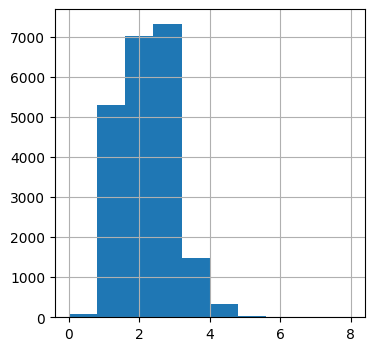

In [1411]:
data['No of Bathrooms'].hist(figsize=(4,4))

<Axes: >

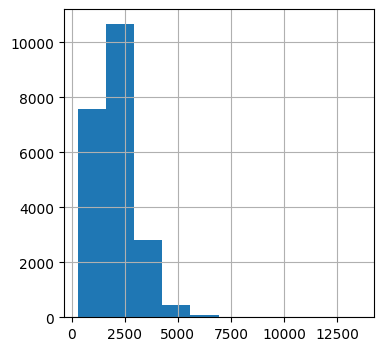

In [1412]:
data['Flat Area (in Sqft)'].hist(figsize=(4,4))

<Axes: >

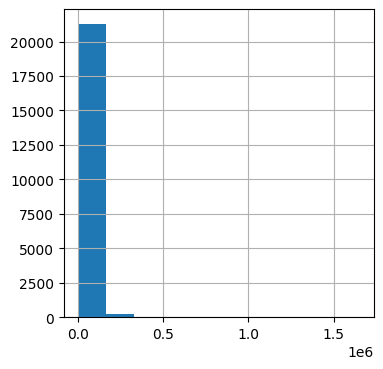

In [1413]:
data['Lot Area (in Sqft)'].hist(figsize=(4,4))

<Axes: >

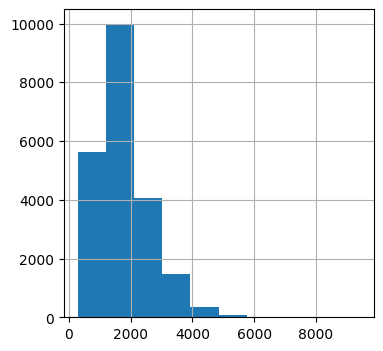

In [1414]:
data['Area of the House from Basement (in Sqft)'].hist(figsize=(4,4))

<Axes: >

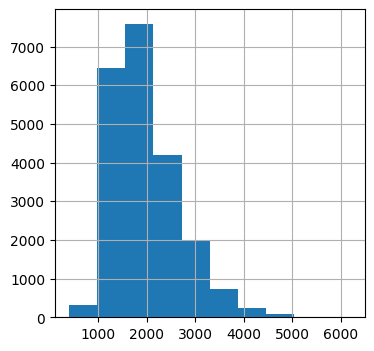

In [1415]:
data['Living Area after Renovation (in Sqft)'].hist(figsize=(4,4))

In [1416]:
data['Flat Area (in Sqft)'] = data['Flat Area (in Sqft)'].fillna(data['Flat Area (in Sqft)'].median())

In [1417]:
data['Lot Area (in Sqft)'] = data['Lot Area (in Sqft)'].fillna(data['Lot Area (in Sqft)'].median())

In [1418]:
data['No of Bathrooms'] = data['No of Bathrooms'].fillna(data['No of Bathrooms'].median())

In [1419]:
data['Area of the House from Basement (in Sqft)'] = data['Area of the House from Basement (in Sqft)'].fillna(data['Area of the House from Basement (in Sqft)'].median())

In [1420]:
data['Zipcode'] = data['Zipcode'].fillna(data['Zipcode'].mode()[0])

In [1421]:
data['No of Bathrooms'] = data['No of Bathrooms'].fillna(data['No of Bathrooms'].median())

In [1422]:
data['Living Area after Renovation (in Sqft)'] = data['Living Area after Renovation (in Sqft)'].fillna(data['No of Bathrooms'].median())

In [1423]:
data = data.dropna(subset = ['Latitude'])

In [1424]:
data = data.dropna(subset = ['Longitude'])

In [1425]:
data.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0
Area of the House from Basement (in Sqft),0


#Outliers

In [1426]:
num_column = data.select_dtypes(include = ['float64', 'int64'])

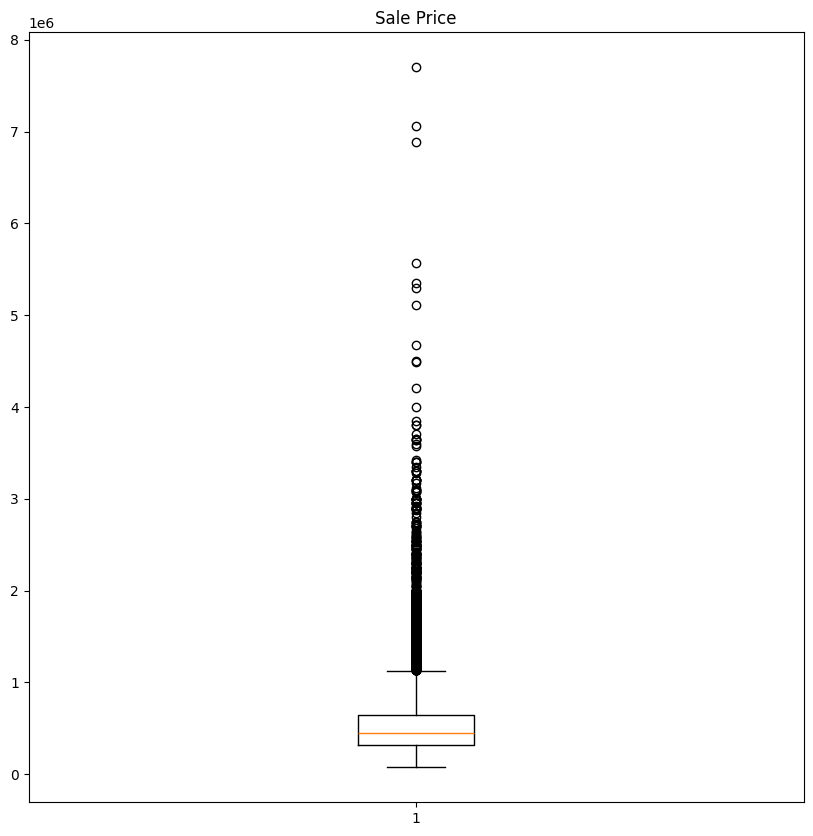

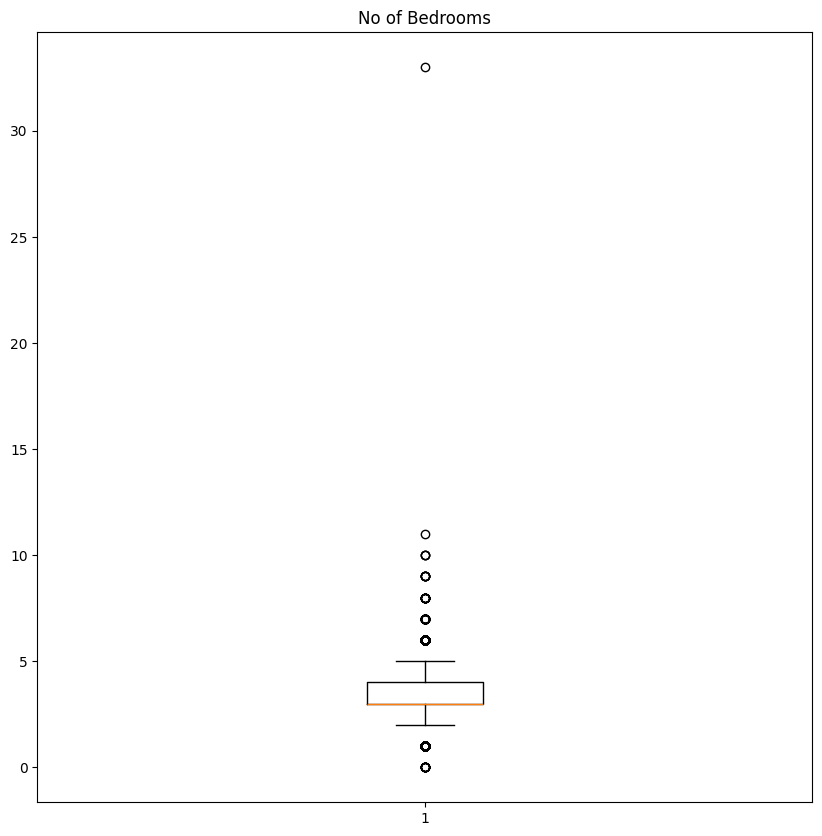

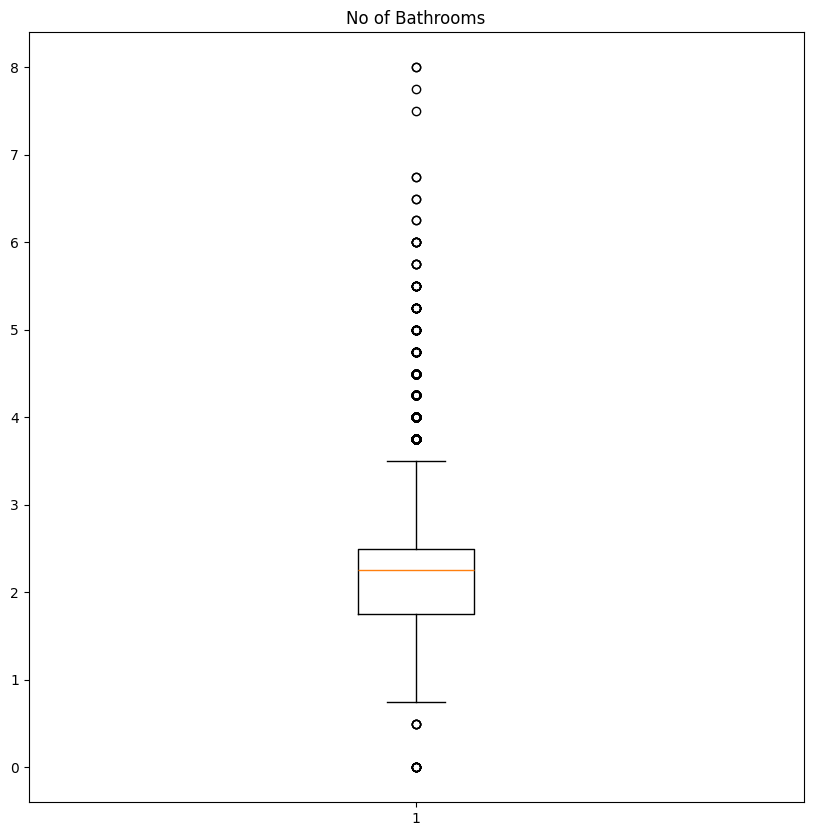

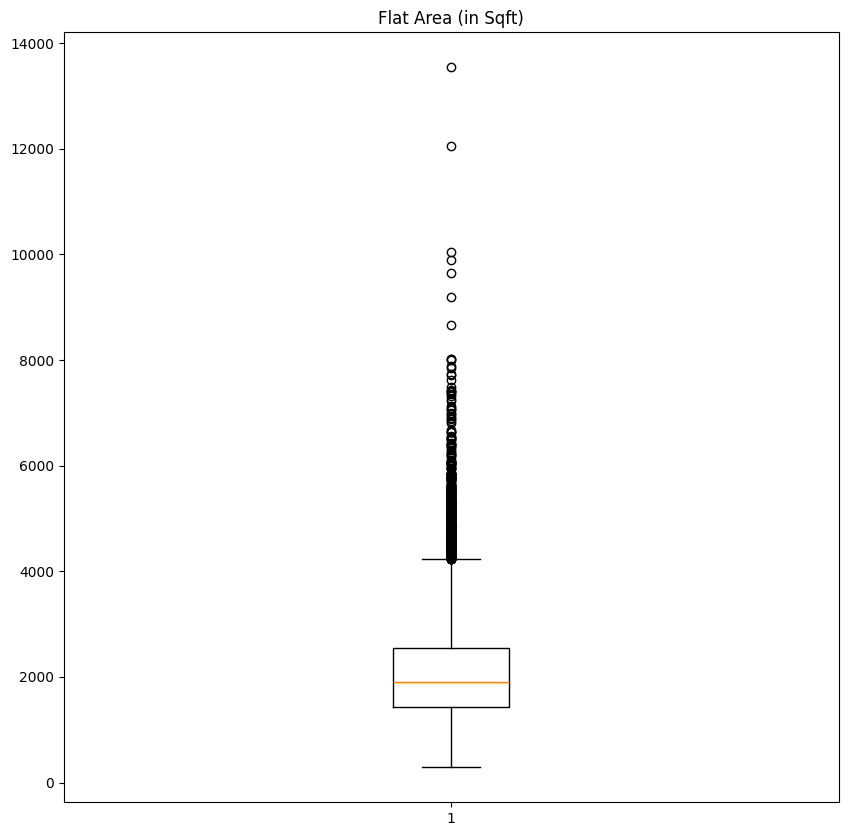

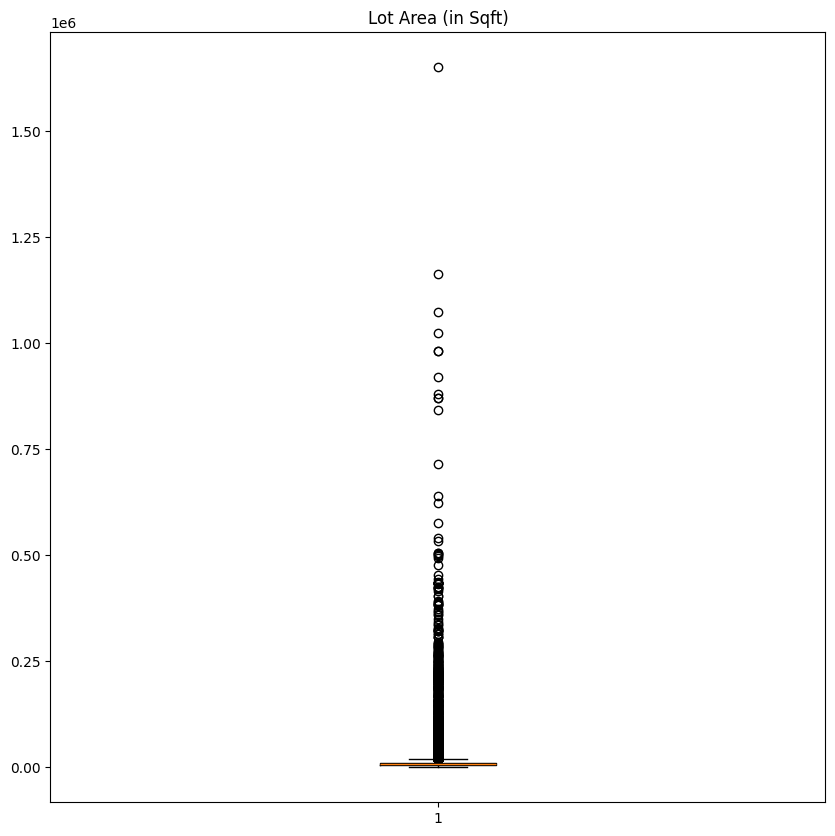

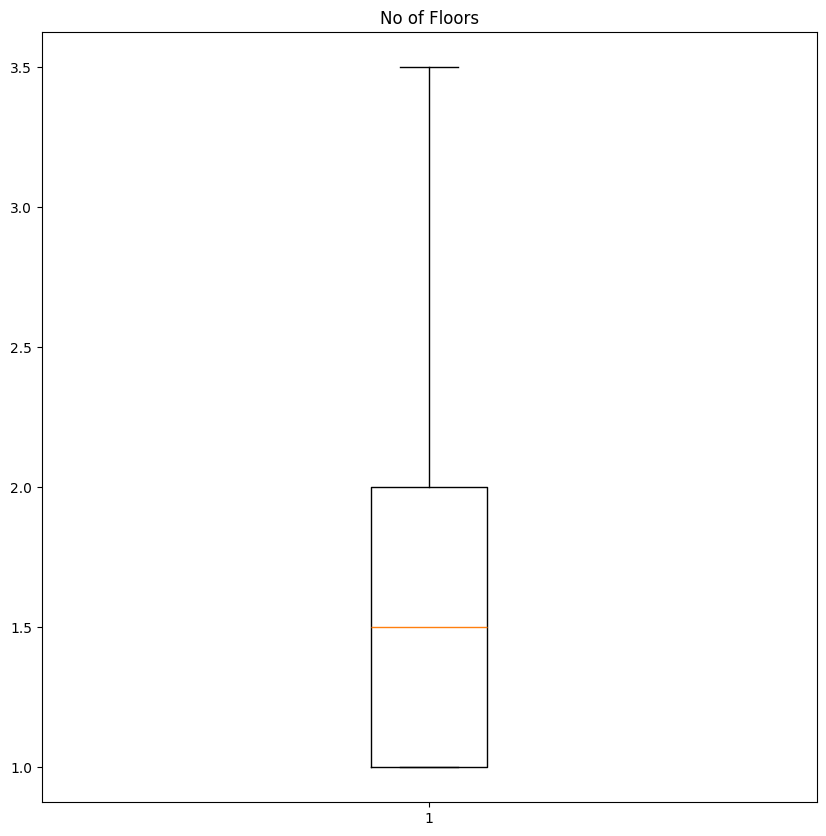

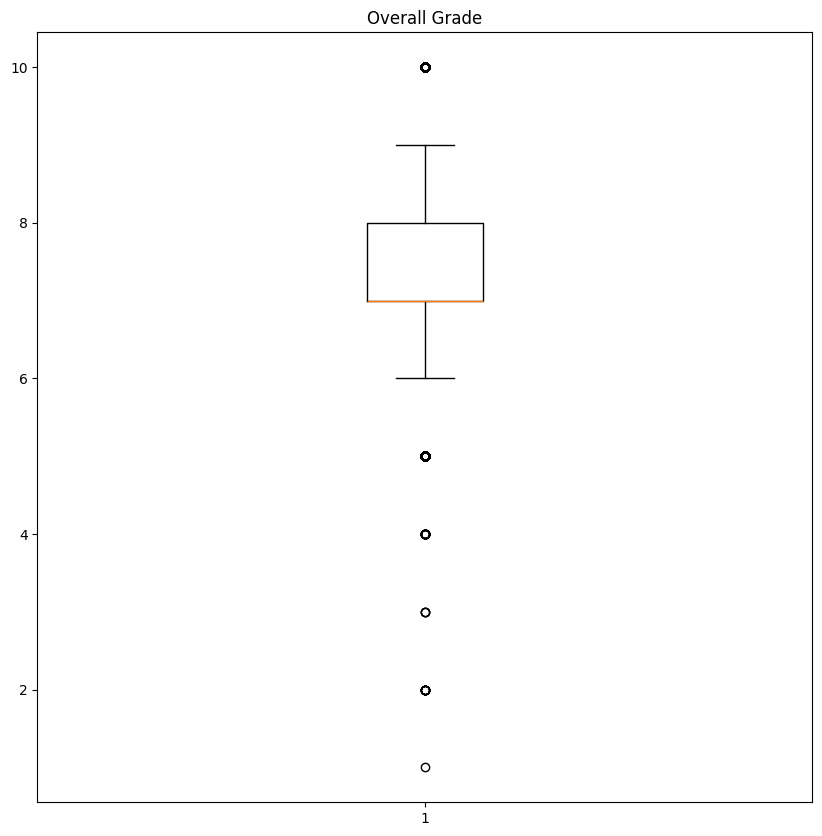

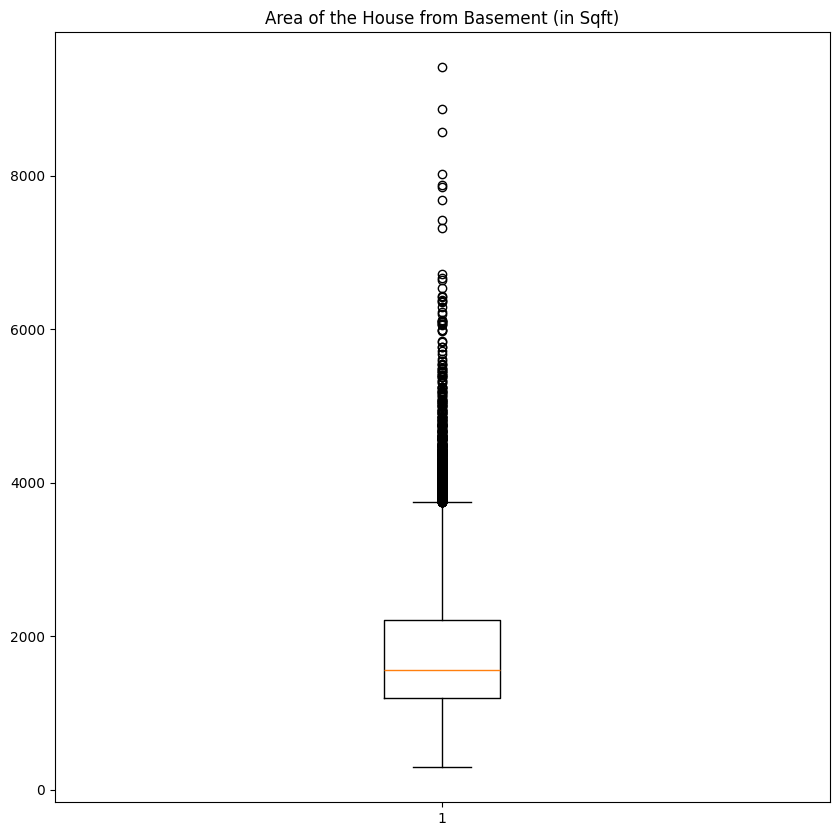

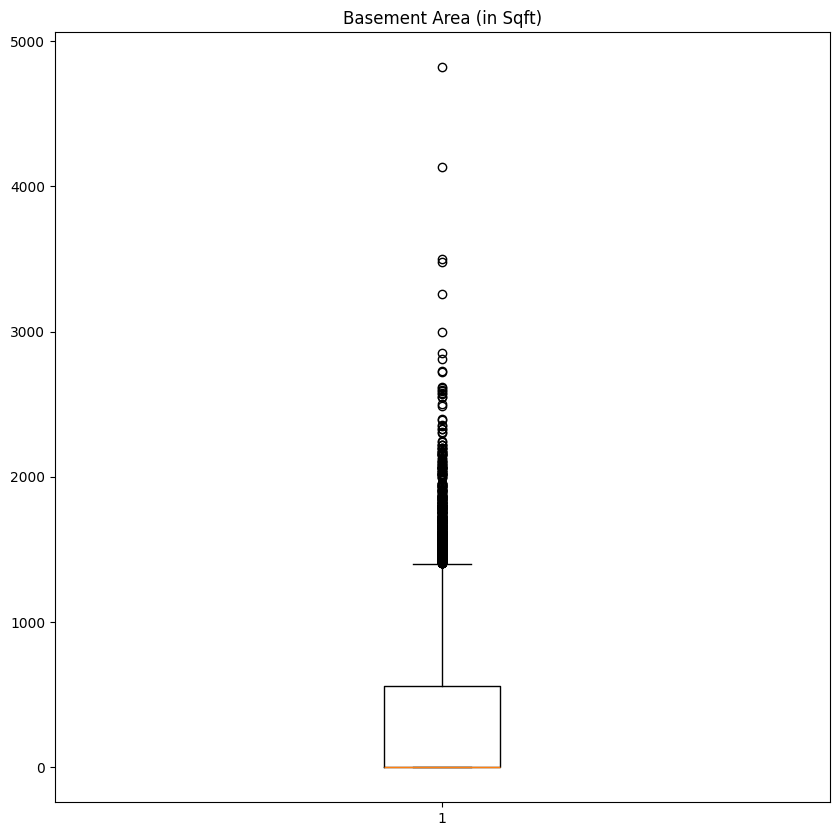

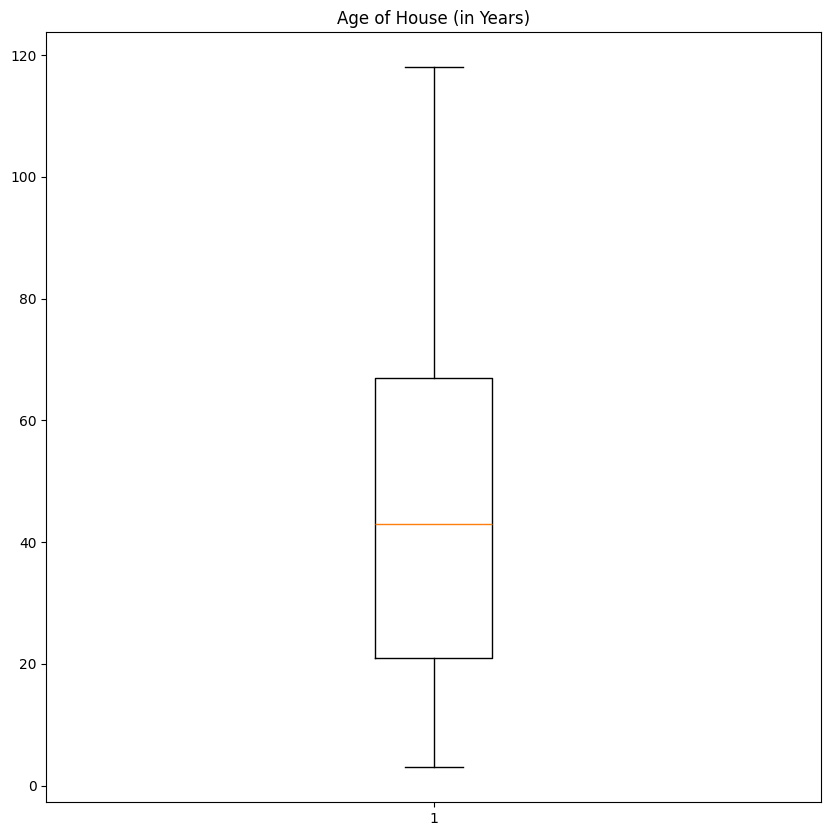

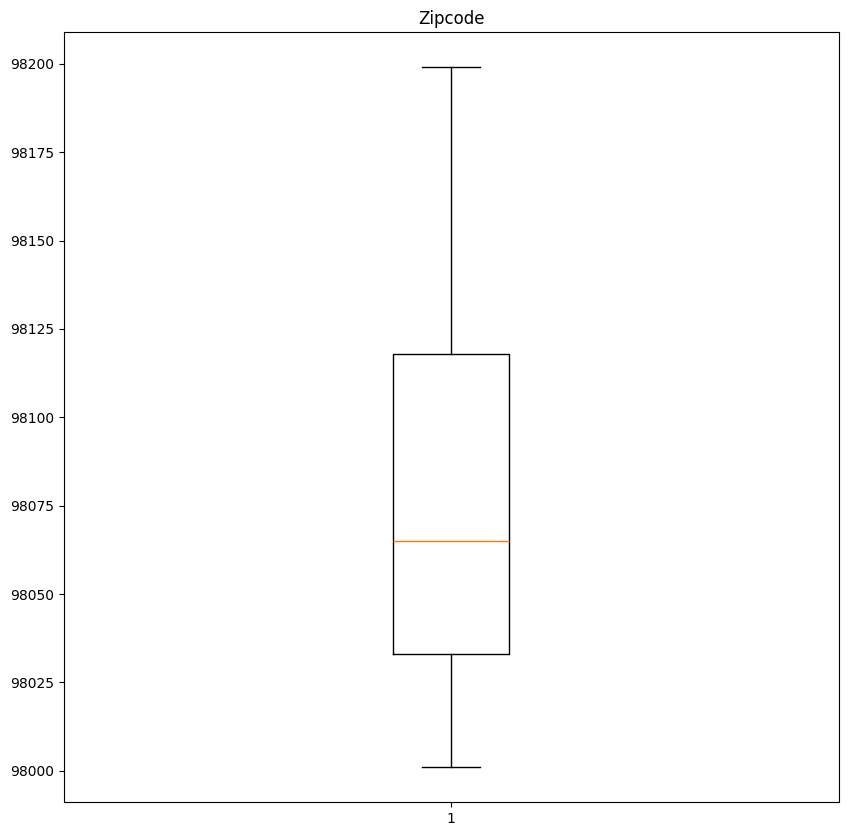

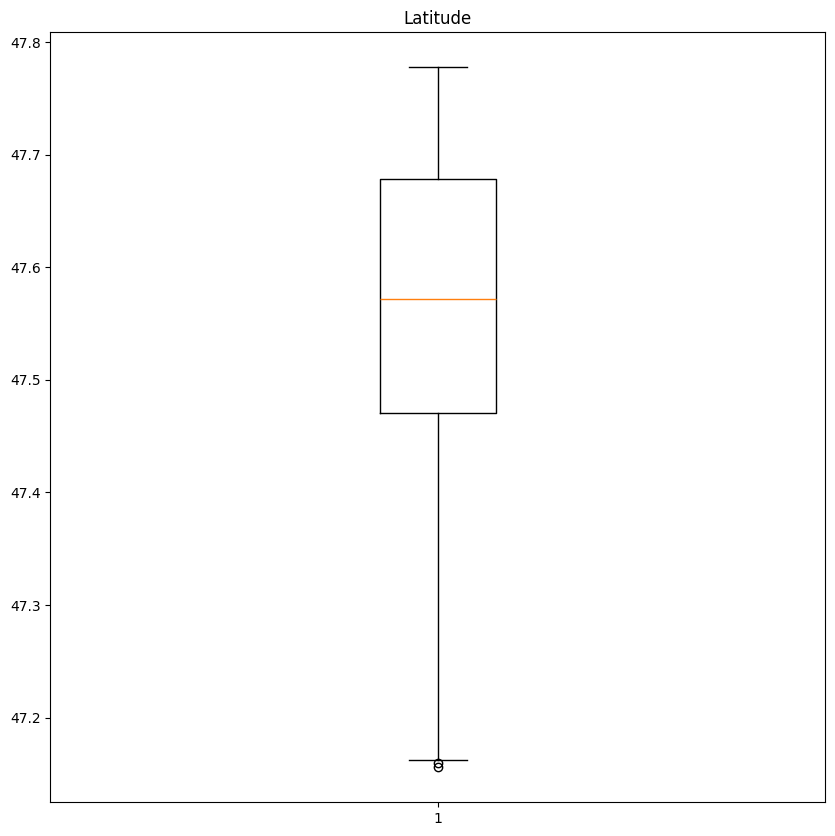

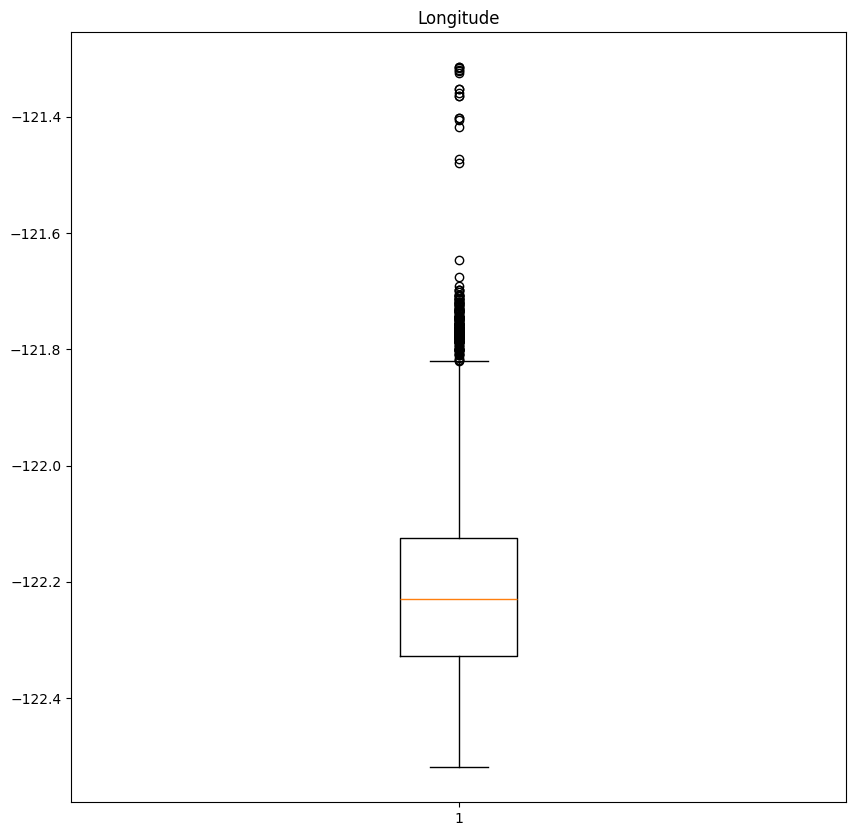

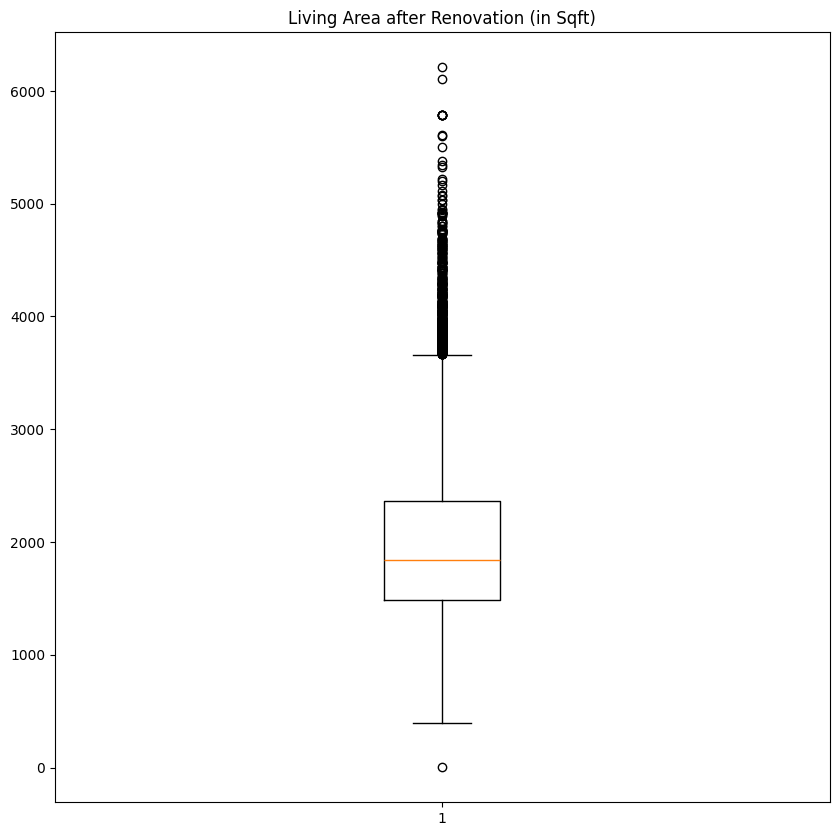

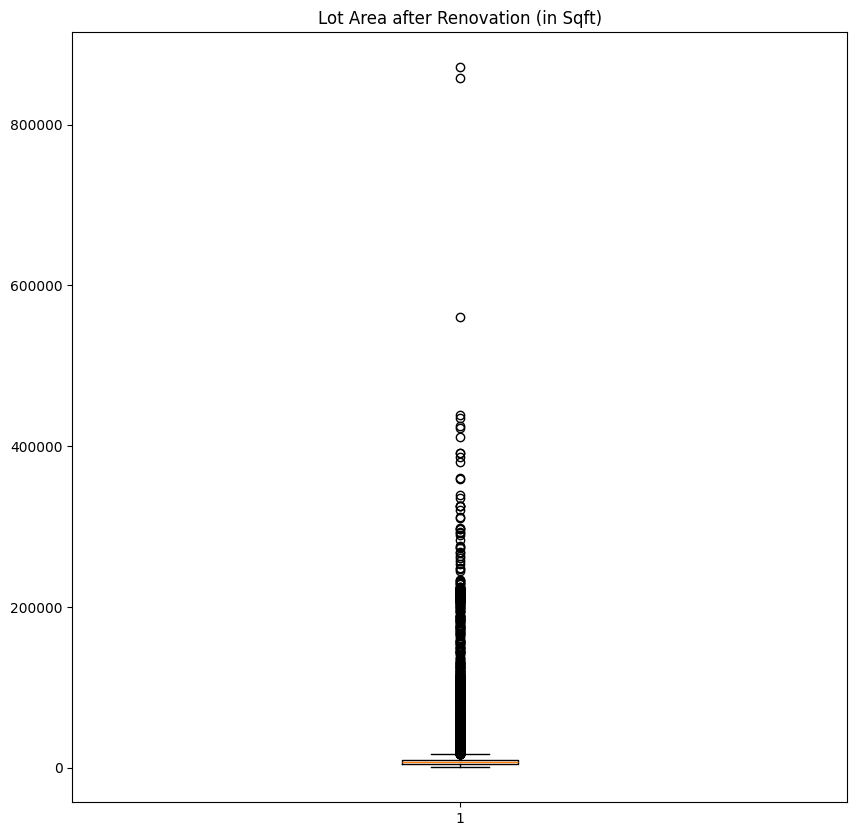

In [1427]:
for i in num_column:
  plt.figure(figsize=(10,10))
  plt.boxplot(data[i])
  plt.title(i)

In [1428]:
q1 = np.quantile(data['No of Bathrooms'], 0.25)
q3 = np.quantile(data['No of Bathrooms'], 0.75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)
lower_bound = q1 - (1.5 * iqr)
print(upper_bound)
print(lower_bound)
print(iqr)

3.625
0.625
0.75


In [1429]:
data['No of Bathrooms'] = data['No of Bathrooms'].clip(lower = lower_bound, upper = upper_bound)

In [1430]:
q1 = np.quantile(data['No of Bedrooms'], 0.25)
q3 = np.quantile(data['No of Bedrooms'], 0.75)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)
lower_bound = q1 - (1.5 * iqr)
print(upper_bound)
print(lower_bound)
print(iqr)

5.5
1.5
1.0


In [1431]:
data['No of Bedrooms'] = data['No of Bedrooms'].clip(lower = lower_bound, upper = upper_bound)

{'whiskers': [<matplotlib.lines.Line2D at 0x7d941bbaa990>,
 'caps': [<matplotlib.lines.Line2D at 0x7d941bbaaf30>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d941b17bc80>],
 'medians': [<matplotlib.lines.Line2D at 0x7d941879c440>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d941879ef90>],
 'means': []}

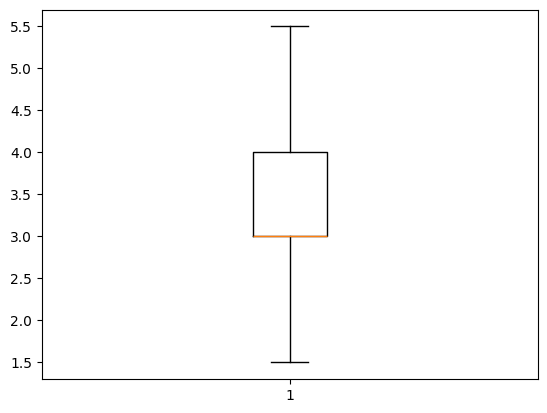

In [1432]:
plt.boxplot(data['No of Bedrooms'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7d941a80fec0>,
 'caps': [<matplotlib.lines.Line2D at 0x7d941a80e120>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d941a80f740>],
 'medians': [<matplotlib.lines.Line2D at 0x7d941a80ca40>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d941a80c740>],
 'means': []}

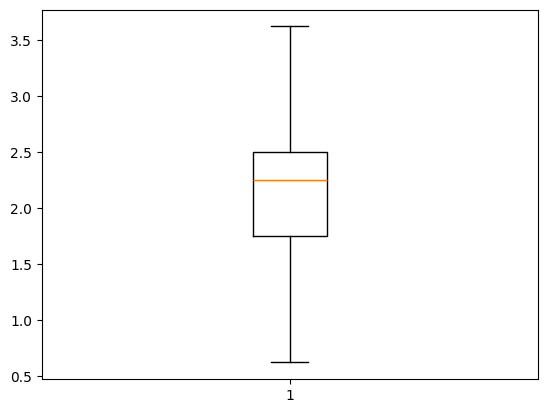

In [1433]:
plt.boxplot(data['No of Bathrooms'])

In [1434]:
data['Flat Area (in Sqft)'] = np.log1p(data['Flat Area (in Sqft)'])

In [1435]:
data['Lot Area (in Sqft)'] = np.log1p(data['Lot Area (in Sqft)'])

In [1436]:
data['Area of the House from Basement (in Sqft)'] = np.log1p(data['Area of the House from Basement (in Sqft)'])

In [1437]:
data['Basement Area (in Sqft)'] = np.log1p(data['Basement Area (in Sqft)'])

In [1438]:
data['Living Area after Renovation (in Sqft)'] = np.log1p(data['Living Area after Renovation (in Sqft)'])

In [1439]:
data['Lot Area after Renovation (in Sqft)'] = np.log1p(data['Lot Area after Renovation (in Sqft)'])

In [1440]:
data['Sale Price'] = np.log1p(data['Sale Price'])

In [1441]:
from scipy.stats.mstats import winsorize

In [1442]:
data['Longitude'] = winsorize(data['Longitude'], limits=[0.05, 0.05])

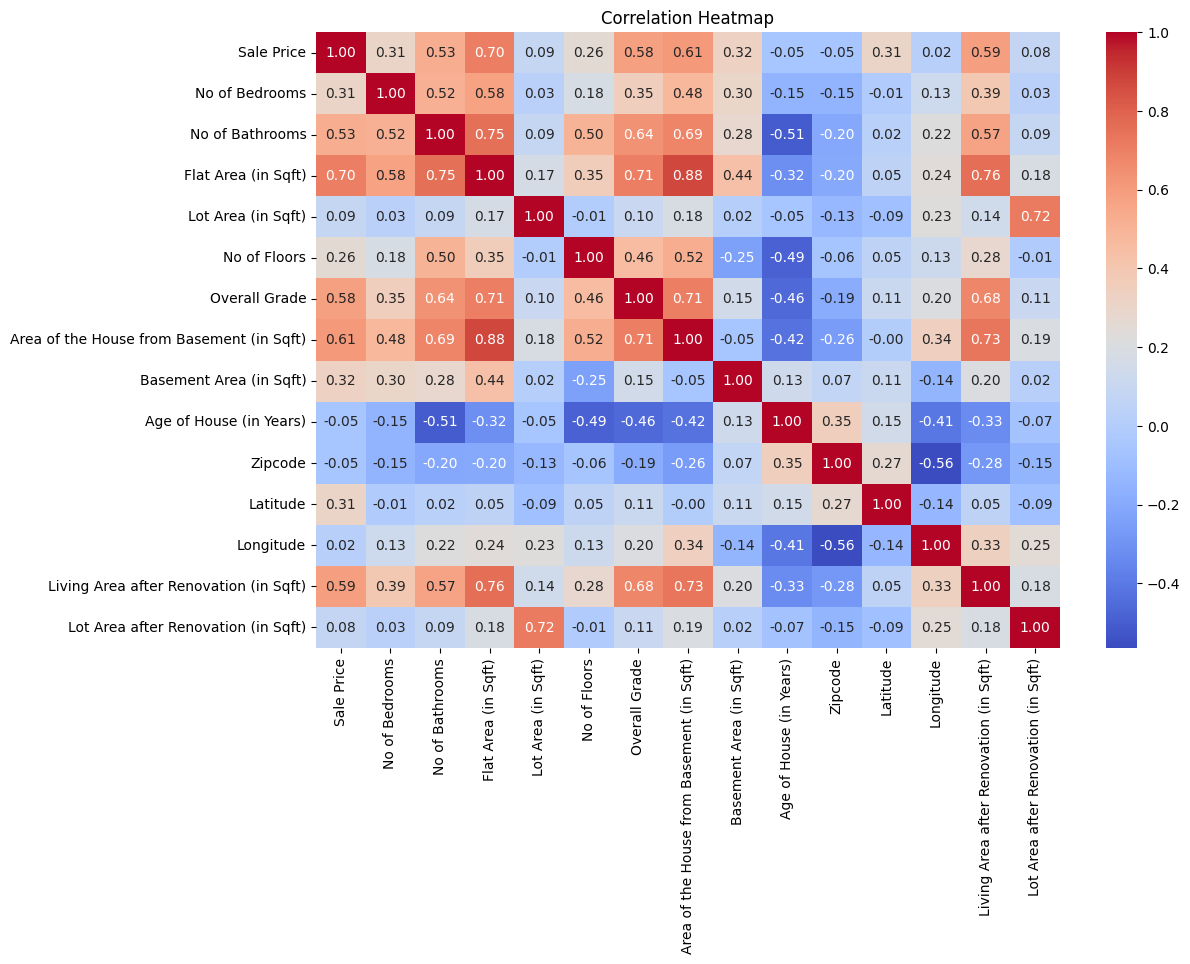

In [1443]:
corr = num_column.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

#Encoding

In [1444]:
data

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,12.309987,3.0,1.00,7.074117,8.639588,1.0,No,Fair,7,7.074117,0.000000,63,98178.0,47.5112,-122.257,7.201171,8.639588
1,13.195616,3.0,2.25,7.852050,8.887791,2.0,No,Fair,7,7.682943,5.993961,67,98125.0,47.7210,-122.319,7.433075,8.941153
2,12.100718,2.0,1.00,6.647688,9.210440,1.0,No,Fair,6,6.647688,0.000000,85,98028.0,47.7379,-122.233,7.908755,8.995041
3,13.311331,4.0,3.00,7.581210,8.517393,1.0,No,Excellent,7,6.957497,6.814543,53,98136.0,47.5208,-122.387,7.215975,8.517393
4,13.142168,3.0,2.00,7.427144,8.997271,1.0,No,Fair,8,7.427144,0.000000,31,98074.0,47.6168,-122.045,7.496097,8.923191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,12.793862,3.0,2.50,7.333676,7.031741,3.0,No,Fair,8,7.333676,0.000000,9,98103.0,47.6993,-122.346,7.333676,7.319865
21609,12.899222,4.0,2.50,7.745436,8.668024,2.0,No,Fair,8,7.745436,0.000000,4,98146.0,47.5107,-122.362,7.512618,8.881975
21610,12.904461,2.0,0.75,6.928538,7.208600,2.0,No,Fair,7,6.928538,0.000000,9,98144.0,47.5944,-122.299,6.928538,7.604894
21611,12.899222,3.0,2.50,7.378384,7.778630,2.0,No,Fair,8,7.378384,0.000000,14,98027.0,47.5345,-122.069,7.252054,7.160846


In [1445]:
data['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [1446]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc = OrdinalEncoder(categories= [['Bad', 'Okay', 'Fair','Good', 'Excellent' ]]) #OrdinalEncoder is a class that is imported to key/instance ordinal_enc
data['Condition of the House'] = ordinal_enc.fit_transform(data[['Condition of the House']])

In [1447]:
data = pd.get_dummies(data,
                      columns = ['Waterfront View'],
                      prefix = 'WV',
                      drop_first = True,
                      dtype = 'int64')

In [1448]:
data['Zipcode'] = data['Zipcode'].astype(str)
freq_encoding = data['Zipcode'].value_counts()
data['Zipcode'] = data['Zipcode'].map(freq_encoding)

In [1449]:
data

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),WV_Yes
0,12.309987,3.0,1.00,7.074117,8.639588,1.0,2.0,7,7.074117,0.000000,63,262,47.5112,-122.257,7.201171,8.639588,0
1,13.195616,3.0,2.25,7.852050,8.887791,2.0,2.0,7,7.682943,5.993961,67,410,47.7210,-122.319,7.433075,8.941153,0
2,12.100718,2.0,1.00,6.647688,9.210440,1.0,2.0,6,6.647688,0.000000,85,283,47.7379,-122.233,7.908755,8.995041,0
3,13.311331,4.0,3.00,7.581210,8.517393,1.0,4.0,7,6.957497,6.814543,53,263,47.5208,-122.387,7.215975,8.517393,0
4,13.142168,3.0,2.00,7.427144,8.997271,1.0,2.0,8,7.427144,0.000000,31,441,47.6168,-122.045,7.496097,8.923191,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,12.793862,3.0,2.50,7.333676,7.031741,3.0,2.0,8,7.333676,0.000000,9,602,47.6993,-122.346,7.333676,7.319865,0
21609,12.899222,4.0,2.50,7.745436,8.668024,2.0,2.0,8,7.745436,0.000000,4,288,47.5107,-122.362,7.512618,8.881975,0
21610,12.904461,2.0,0.75,6.928538,7.208600,2.0,2.0,7,6.928538,0.000000,9,343,47.5944,-122.299,6.928538,7.604894,0
21611,12.899222,3.0,2.50,7.378384,7.778630,2.0,2.0,8,7.378384,0.000000,14,412,47.5345,-122.069,7.252054,7.160846,0


#Scaling Numerical Variables

array([[<Axes: title={'center': 'Sale Price'}>,
        <Axes: title={'center': 'No of Bedrooms'}>,
        <Axes: title={'center': 'No of Bathrooms'}>,
        <Axes: title={'center': 'Flat Area (in Sqft)'}>],
       [<Axes: title={'center': 'Lot Area (in Sqft)'}>,
        <Axes: title={'center': 'No of Floors'}>,
        <Axes: title={'center': 'Condition of the House'}>,
        <Axes: title={'center': 'Overall Grade'}>],
       [<Axes: title={'center': 'Area of the House from Basement (in Sqft)'}>,
        <Axes: title={'center': 'Basement Area (in Sqft)'}>,
        <Axes: title={'center': 'Age of House (in Years)'}>,
        <Axes: title={'center': 'Zipcode'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'Living Area after Renovation (in Sqft)'}>,
        <Axes: title={'center': 'Lot Area after Renovation (in Sqft)'}>],
       [<Axes: title={'center': 'WV_Yes'}>, <Axes: >, <Axes: >, <Axes: >]],
     

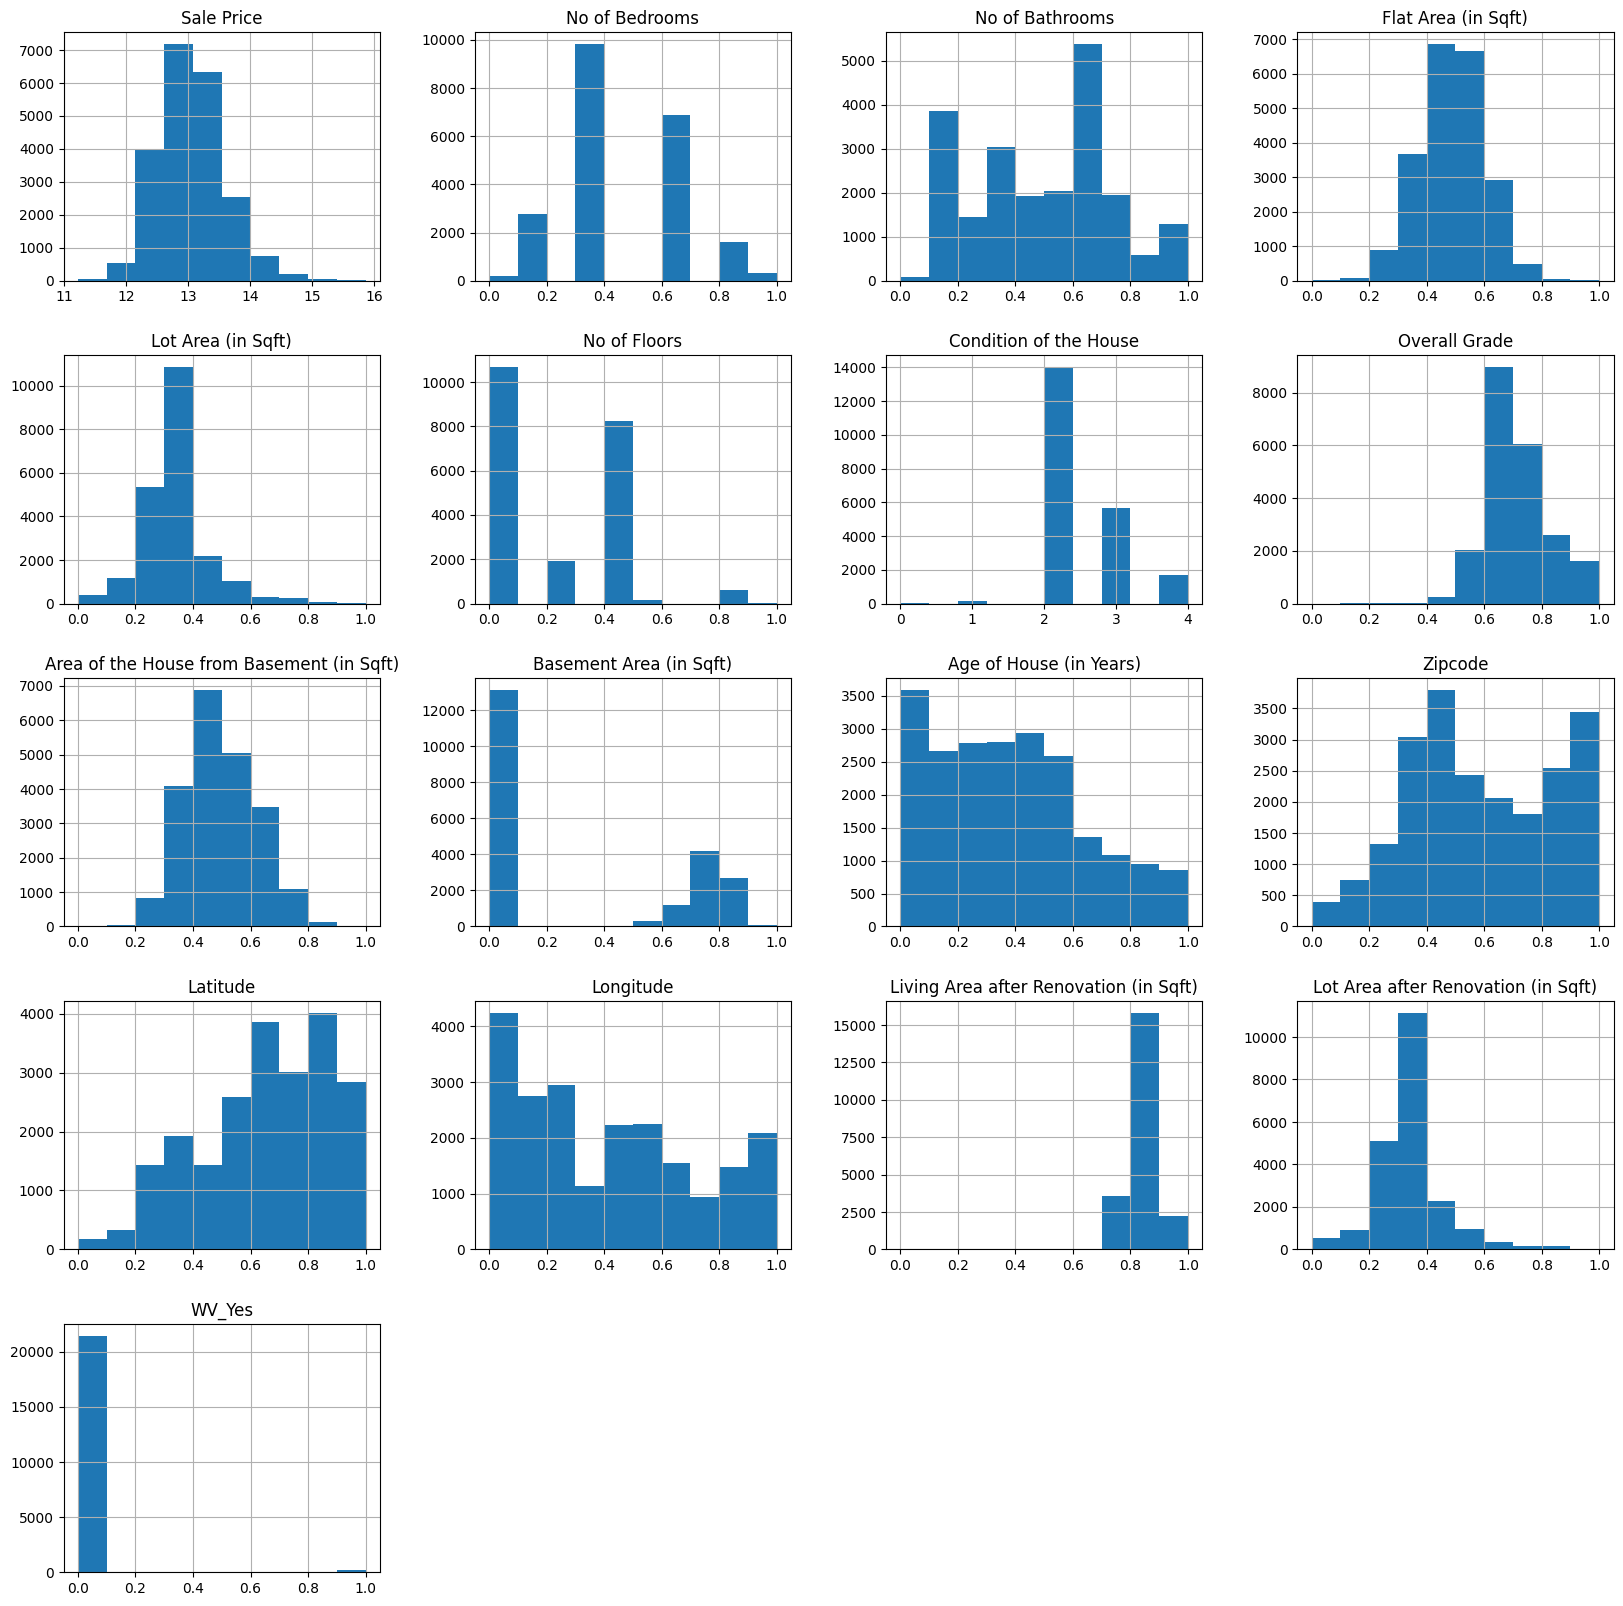

In [1464]:
data.hist(figsize=(20,20))

In [1450]:
columns = ['No of Bedrooms',	'No of Bathrooms',	'Flat Area (in Sqft)', 'Age of House (in Years)',	'Lot Area (in Sqft)',	'No of Floors',	'Overall Grade',	'Area of the House from Basement (in Sqft)',	'Basement Area (in Sqft)',	'Age of House (in Years)',	'Latitude',	'Longitude',	'Living Area after Renovation (in Sqft)', 'Zipcode',	'Lot Area after Renovation (in Sqft)']

In [1451]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
min_scalar = MinMaxScaler()
data[columns] = min_scalar.fit_transform(data[columns])

In [1452]:
data

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),WV_Yes
0,12.309987,0.375,0.125000,0.364775,0.295712,0.0,2.0,0.666667,0.402954,0.000000,0.521739,0.384058,0.571498,0.318627,0.797112,0.300037,0
1,13.195616,0.375,0.541667,0.567354,0.326501,0.4,2.0,0.666667,0.578090,0.706774,0.556522,0.652174,0.908959,0.166667,0.827806,0.341935,0
2,12.100718,0.125,0.125000,0.253731,0.366525,0.0,2.0,0.555556,0.280287,0.000000,0.713043,0.422101,0.936143,0.377451,0.890764,0.349422,0
3,13.311331,0.625,0.791667,0.496826,0.280554,0.0,4.0,0.666667,0.369407,0.803532,0.434783,0.385870,0.586939,0.000000,0.799071,0.283060,0
4,13.142168,0.375,0.458333,0.456706,0.340082,0.0,2.0,0.777778,0.504506,0.000000,0.243478,0.708333,0.741354,0.838235,0.836147,0.339440,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,12.793862,0.375,0.625000,0.432366,0.096261,0.8,2.0,0.777778,0.477619,0.000000,0.052174,1.000000,0.874055,0.100490,0.814650,0.116681,0
21609,12.899222,0.625,0.625000,0.539591,0.299239,0.4,2.0,0.777778,0.596066,0.000000,0.008696,0.431159,0.570693,0.061275,0.838333,0.333713,0
21610,12.904461,0.125,0.041667,0.326866,0.118200,0.4,2.0,0.666667,0.361077,0.000000,0.052174,0.530797,0.705324,0.215686,0.761027,0.156282,0
21611,12.899222,0.375,0.625000,0.444008,0.188911,0.4,2.0,0.777778,0.490480,0.000000,0.095652,0.655797,0.608975,0.779412,0.803846,0.094587,0


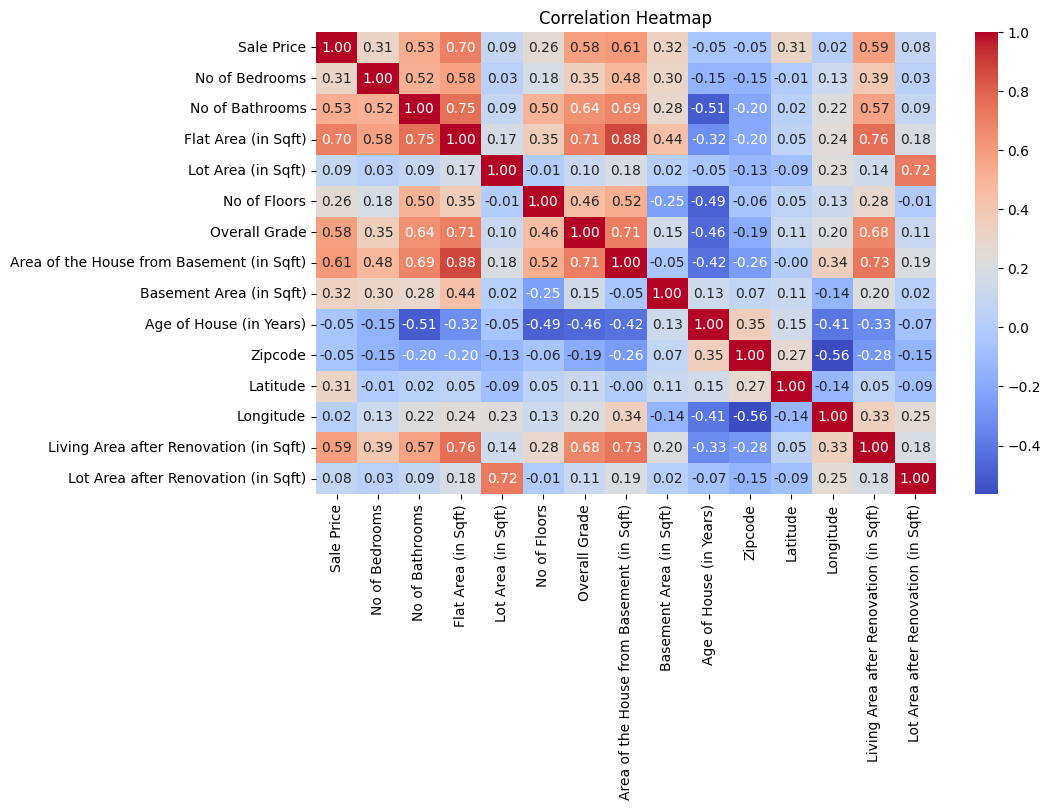

In [1453]:
corr = num_column.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

#Train-Test Split

In [1454]:
X = data[['No of Bedrooms',	'No of Bathrooms',	'Flat Area (in Sqft)',	'Lot Area (in Sqft)',	'No of Floors',	'Condition of the House',	'Overall Grade',	'Basement Area (in Sqft)',	'Age of House (in Years)', 'Zipcode',	'Latitude',	'Longitude',	'Living Area after Renovation (in Sqft)',	'Lot Area after Renovation (in Sqft)',	'WV_Yes']]

In [1455]:
y=data['Sale Price']

In [1456]:
from sklearn.model_selection import train_test_split

In [1457]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [1461]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(17285, 15)
(4322, 15)
(17285,)
(4322,)


In [1465]:
data.to_excel('data_cleaned.xlsx')